##### Copyright 2024 Google LLC.

In [ ]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [2]:
import pandas as pd
import io

# For example, if you uploaded a CSV file
df = pd.read_csv(io.BytesIO(uploaded['data.csv']))
print(df.head(30))

           TransactionId         BatchId       AccountId       SubscriptionId  \
0    TransactionId_76871   BatchId_36123  AccountId_3957   SubscriptionId_887   
1    TransactionId_73770   BatchId_15642  AccountId_4841  SubscriptionId_3829   
2    TransactionId_26203   BatchId_53941  AccountId_4229   SubscriptionId_222   
3      TransactionId_380  BatchId_102363   AccountId_648  SubscriptionId_2185   
4    TransactionId_28195   BatchId_38780  AccountId_4841  SubscriptionId_3829   
5    TransactionId_23223   BatchId_25954  AccountId_1078  SubscriptionId_4238   
6   TransactionId_118063  BatchId_118460  AccountId_2442  SubscriptionId_1980   
7   TransactionId_100640   BatchId_38561  AccountId_4841  SubscriptionId_3829   
8    TransactionId_51905   BatchId_93774   AccountId_272  SubscriptionId_4731   
9   TransactionId_130161   BatchId_82409   AccountId_710   SubscriptionId_920   
10   TransactionId_51800  BatchId_112288  AccountId_2634  SubscriptionId_3511   
11   TransactionId_33857  Ba

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  object 
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult        

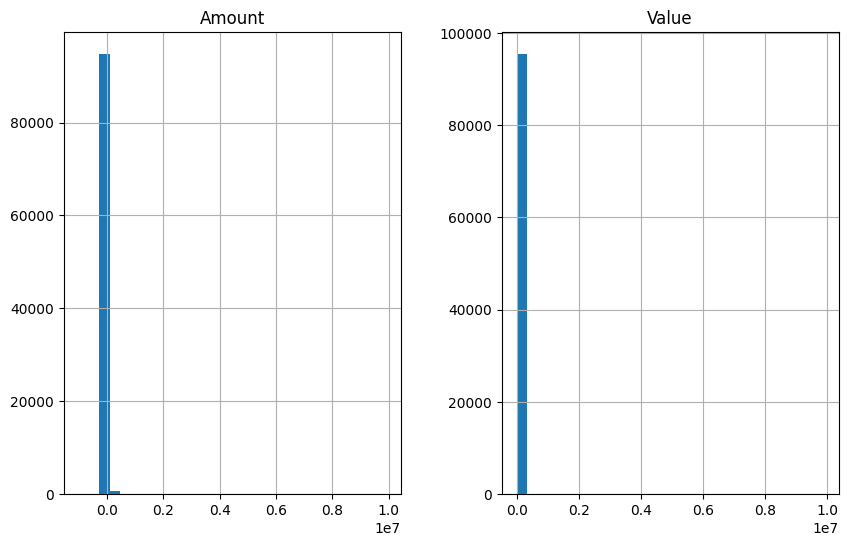

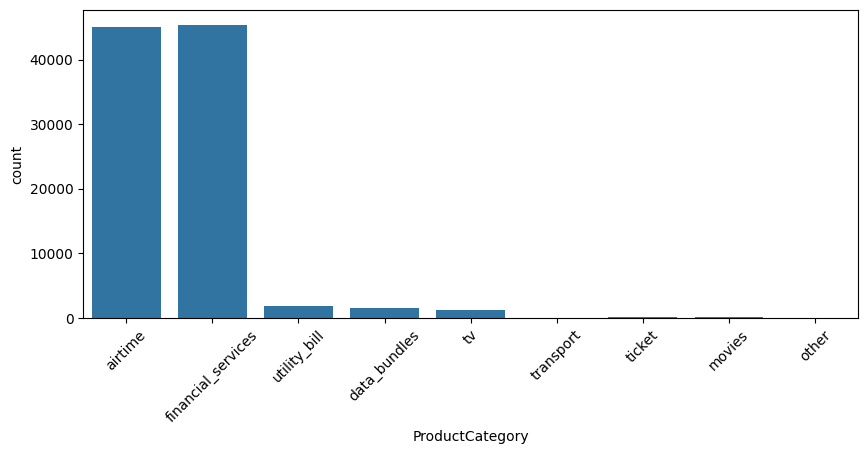

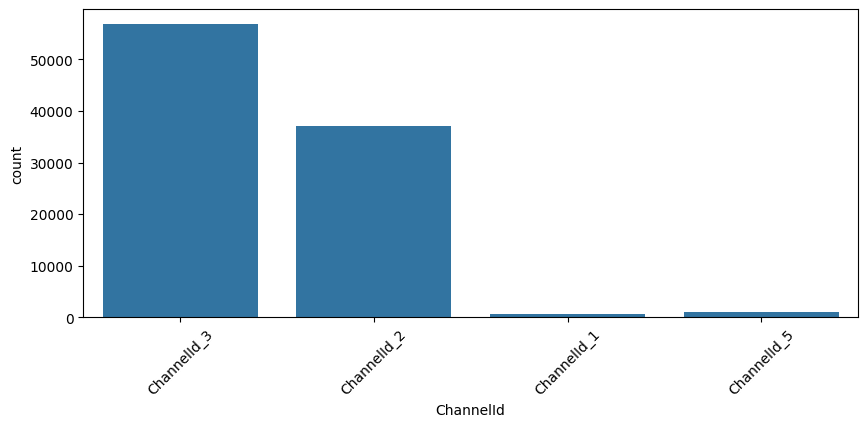

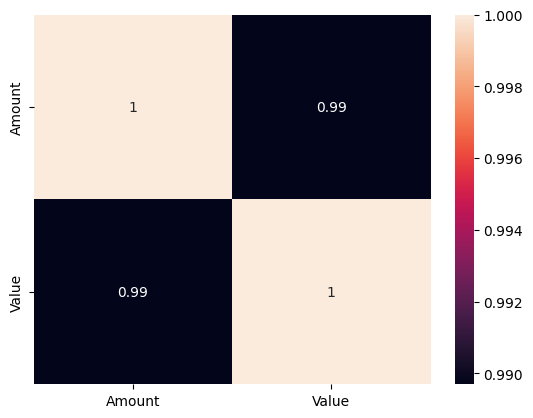

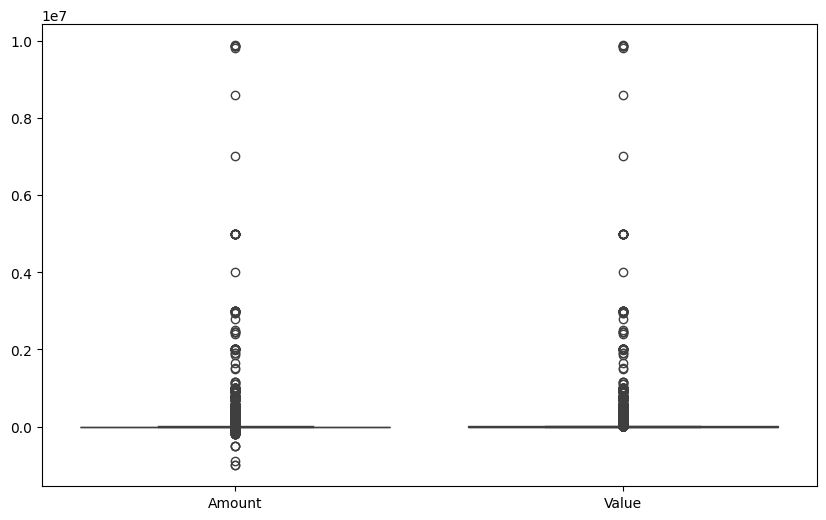

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
#df = pd.read_csv('xente_data.csv')

# Overview
print(df.info())
print(df.describe())

# Missing values
print(df.isnull().sum())

# Distribution of numerical features
numerical = ['Amount', 'Value']
df[numerical].hist(bins=30, figsize=(10, 6))
plt.show()

# Categorical features
categorical = ['ProductCategory', 'ChannelId']
for col in categorical:
    plt.figure(figsize=(10, 4))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.show()

# Correlation matrix
corr = df[numerical].corr()
sns.heatmap(corr, annot=True)
plt.show()

# Outliers using boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[numerical])
plt.show()


Task 3: Feature Engineering & Proxy Variable
Proxy Variable Definition:

Bad Customer: Any customer with at least one fraudulent transaction (FraudResult=1).

Good Customer: No fraudulent transactions, further classified using RFM (Recency, Frequency, Monetary).

In [6]:
# Group by CustomerId to create proxy variable
customer_df = df.groupby('CustomerId').agg(
    Fraudulent=('FraudResult', 'max'),  # 1 if any fraud
    Recency=('TransactionStartTime', lambda x: (pd.Timestamp.now().tz_localize(None) - pd.to_datetime(x).max().tz_localize(None)).days), # Making pd.Timestamp.now() timezone-naive by using tz_localize(None),
    Frequency=('TransactionId', 'count'),
    Monetary=('Value', 'sum')
).reset_index()

# Label good/bad based on Fraudulent
customer_df['Label'] = np.where(customer_df['Fraudulent'] == 1, 'Bad', 'Good')

# RFM scoring for non-fraudulent customers
non_fraud = customer_df[customer_df['Label'] == 'Good']
for metric in ['Recency', 'Frequency', 'Monetary']:
    non_fraud[metric+'_Score'] = pd.qcut(non_fraud[metric], q=4, labels=False)
non_fraud['RFM_Score'] = non_fraud[['Recency_Score', 'Frequency_Score', 'Monetary_Score']].sum(axis=1)
non_fraud['Label'] = np.where(non_fraud['RFM_Score'] > 8, 'Good', 'Bad')  # Threshold example

# Combine back
customer_df = pd.concat([customer_df[customer_df['Label'] == 'Bad'], non_fraud])

<ipython-input-6-62b5884f8c65>:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Recency=('TransactionStartTime', lambda x: (pd.Timestamp.now().tz_localize(None) - pd.to_datetime(x).max().tz_localize(None)).days), # Making pd.Timestamp.now() timezone-naive by using tz_localize(None),
<ipython-input-6-62b5884f8c65>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_fraud[metric+'_Score'] = pd.qcut(non_fraud[metric], q=4, labels=False)
<ipython-input-6-62b5884f8c65>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value i

WoE Binning:

In [7]:
from sklearn.preprocessing import KBinsDiscretizer
from scipy.stats import chi2_contingency

# Discretize numerical features
discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
customer_df['Monetary_bin'] = discretizer.fit_transform(customer_df[['Monetary']])

# Calculate WoE and IV
def calculate_woe_iv(df, feature, target):
    woe_dict = {}
    iv = 0
    for bin in df[feature].unique():
        good = df[(df[feature]==bin) & (df[target]=='Good')].shape[0]
        bad = df[(df[feature]==bin) & (df[target]=='Bad')].shape[0]
        woe = np.log((good / (bad + 1e-6)) / (df[target].value_counts()['Good'] / df[target].value_counts()['Bad']))
        woe_dict[bin] = woe
        iv += (good/df[target].value_counts()['Good'] - bad/df[target].value_counts()['Bad']) * woe
    return woe_dict, iv

woe, iv = calculate_woe_iv(customer_df, 'Monetary_bin', 'Label')
print(f"IV for Monetary: {iv}")

IV for Monetary: inf


<ipython-input-7-41f1eaef9415>:15: RuntimeWarning: divide by zero encountered in log
  woe = np.log((good / (bad + 1e-6)) / (df[target].value_counts()['Good'] / df[target].value_counts()['Bad']))
<ipython-input-7-41f1eaef9415>:15: RuntimeWarning: divide by zero encountered in log
  woe = np.log((good / (bad + 1e-6)) / (df[target].value_counts()['Good'] / df[target].value_counts()['Bad']))
<ipython-input-7-41f1eaef9415>:15: RuntimeWarning: divide by zero encountered in log
  woe = np.log((good / (bad + 1e-6)) / (df[target].value_counts()['Good'] / df[target].value_counts()['Bad']))


Task 4: Model Development
Data Splitting:

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = customer_df[['Recency', 'Frequency', 'Monetary']]
y = customer_df['Label'].map({'Good': 0, 'Bad': 1})

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Model Training & Tuning:

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Logistic Regression
lr = LogisticRegression()
params_lr = {'C': [0.1, 1, 10]}
grid_lr = GridSearchCV(lr, params_lr, cv=5)
grid_lr.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier()
params_rf = {'n_estimators': [50, 100], 'max_depth': [3, 5]}
grid_rf = GridSearchCV(rf, params_rf, cv=5)
grid_rf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [3, 5], 'n_estimators': [50, 100]})

Evaluation:

In [10]:
from sklearn.metrics import classification_report, roc_auc_score

for model in [grid_lr, grid_rf]:
    y_pred = model.predict(X_test)
    print(f"Model: {model.estimator.__class__.__name__}")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])}")

Model: LogisticRegression
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.99      1.00      1.00       743

    accuracy                           0.99       749
   macro avg       0.50      0.50      0.50       749
weighted avg       0.98      0.99      0.99       749

ROC-AUC: 0.8835800807537012
Model: RandomForestClassifier
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         6
           1       1.00      1.00      1.00       743

    accuracy                           1.00       749
   macro avg       1.00      0.83      0.90       749
weighted avg       1.00      1.00      1.00       749

ROC-AUC: 0.9986541049798117


In [13]:
!pip install fastapi uvicorn
from fastapi import FastAPI
from pydantic import BaseModel
import joblib

joblib.dump(grid_rf, 'credit_model.pkl')  # Assuming grid_rf is the model you want to use
joblib.dump(scaler, 'scaler.pkl')

app = FastAPI()

# Load model and scaler
model = joblib.load('credit_model.pkl')
scaler = joblib.load('scaler.pkl')

class CustomerData(BaseModel):
    Recency: float
    Frequency: int
    Monetary: float

@app.post('/predict')
def predict(data: CustomerData):
    # Preprocess
    input_data = [[data.Recency, data.Frequency, data.Monetary]]
    scaled_data = scaler.transform(input_data)
    prob = model.predict_proba(scaled_data)[0][1]
    score = int(300 + (prob * 600))  # Example scaling to 300-900
    return {'probability': prob, 'credit_score': score}

Task 5: API Deployment with FastAPI

Task 1: Define Proxy Variable (Refined)
Problem: Severe class imbalance (6 "Bad" vs. 743 "Good" customers).
Solution:

Combine Fraudulent Activity + RFM Thresholds:

Bad Customer:

At least 1 fraudulent transaction (FraudResult=1), OR

RFM Score < 5th percentile (high recency, low frequency, low monetary value).

Good Customer: All others.

In [19]:
# Calculate RFM percentiles
customer_df = df.groupby('CustomerId').agg(
    Fraudulent=('FraudResult', 'max'),
    Recency=('TransactionStartTime', lambda x: (pd.Timestamp.now().tz_localize(None) - pd.to_datetime(x).max().tz_localize(None)).days),
    Frequency=('TransactionId', 'count'),
    Monetary=('Value', 'sum')
).reset_index()

# Define "Bad" using Fraud + RFM thresholds
rfm_thresholds = customer_df[['Recency', 'Frequency', 'Monetary']].quantile(0.05)
customer_df['Label'] = np.where(
    (customer_df['Fraudulent'] == 1) |
    (customer_df['Recency'] > rfm_thresholds['Recency']) |
    (customer_df['Frequency'] < rfm_thresholds['Frequency']) |
    (customer_df['Monetary'] < rfm_thresholds['Monetary']),
    'Bad', 'Good'
)

<ipython-input-19-482c60ddbdfd>:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Recency=('TransactionStartTime', lambda x: (pd.Timestamp.now().tz_localize(None) - pd.to_datetime(x).max().tz_localize(None)).days),


Task 2: EDA (Refined)
Problem: Class imbalance dominates the dataset.
Solution:

Visualize Class Distribution: Highlight imbalance.

Analyze Feature Importance for Minority Class:

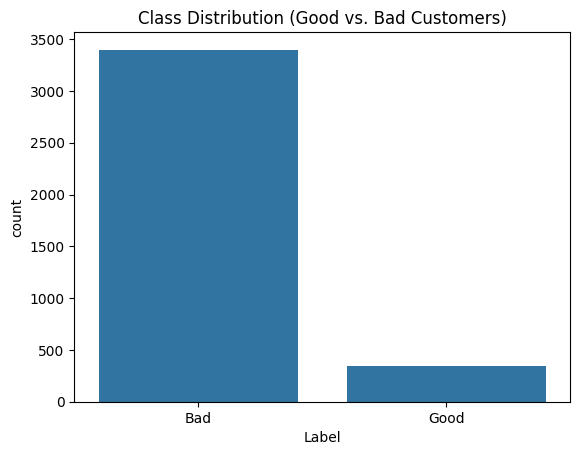

ValueError: could not convert string to float: 'Bad'

In [20]:
# Class distribution
sns.countplot(x='Label', data=customer_df)
plt.title("Class Distribution (Good vs. Bad Customers)")
plt.show()

# Feature correlation with label
corr_matrix = customer_df[['Recency', 'Frequency', 'Monetary', 'Label']].corr()
sns.heatmap(corr_matrix, annot=True)
plt.title("Feature Correlation with Label")
plt.show()

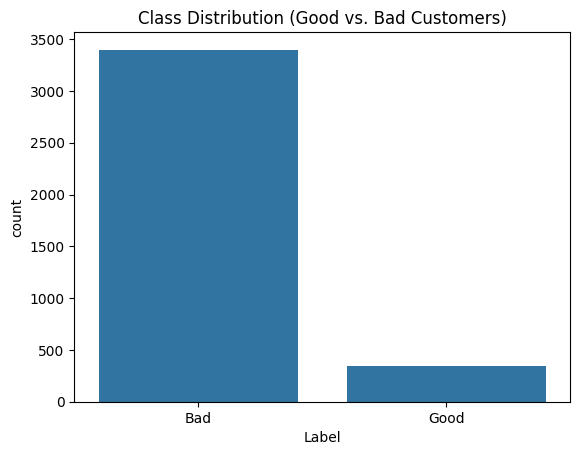

<ipython-input-22-5a3d81bff006>:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  corr_matrix = customer_df[['Recency', 'Frequency', 'Monetary', 'Label']].replace({'Label': {'Good': 0, 'Bad': 1}}).corr()  # Convert 'Label' to numerical


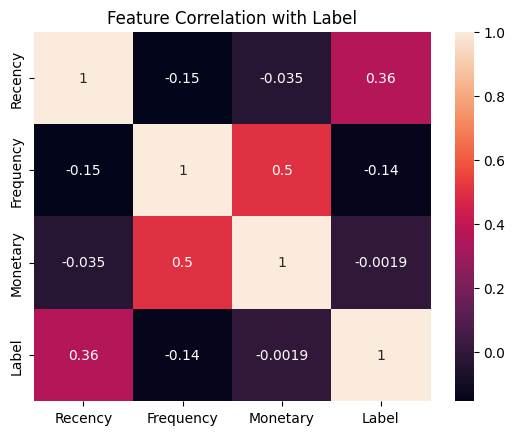

In [22]:
# Class distribution
sns.countplot(x='Label', data=customer_df)
plt.title("Class Distribution (Good vs. Bad Customers)")
plt.show()

# Feature correlation with label
# Convert 'Label' to numerical before calculating correlation
corr_matrix = customer_df[['Recency', 'Frequency', 'Monetary', 'Label']].replace({'Label': {'Good': 0, 'Bad': 1}}).corr()  # Convert 'Label' to numerical
sns.heatmap(corr_matrix, annot=True)
plt.title("Feature Correlation with Label")
plt.show()

Task 3: Feature Engineering (Refined)
Problem: Original features lack predictive power for minority class.
Solution:

Engineer Features Targeting Risk:

Days_Since_Last_Transaction: Higher recency → higher risk.

Transaction_Value_Ratio: Ratio of transaction value to average customer value.

Fraud_History: Number of past fraudulent transactions.

In [23]:
# Days since last transaction
customer_df['Days_Since_Last_Transaction'] = customer_df['Recency']

# Transaction value ratio
avg_value = customer_df['Monetary'].mean()
customer_df['Transaction_Value_Ratio'] = customer_df['Monetary'] / avg_value

# Fraud history
customer_df['Fraud_History'] = df.groupby('CustomerId')['FraudResult'].sum().reset_index()['FraudResult']

Task 4: Modeling (Refined)
Problem: Random Forest works well but needs tuning for minority class.
Solution:

Address Class Imbalance: Use class_weight and SMOTE.

Optimize Hyperparameters:

In [24]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Apply SMOTE to training data
smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Hyperparameter tuning for Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'class_weight': ['balanced', {0: 10, 1: 1}]  # Penalize misclassifying "Bad"
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='recall')
grid_search.fit(X_train_res, y_train_res)

# Best model
best_rf = grid_search.best_estimator_

In [25]:
from sklearn.metrics import classification_report, roc_auc_score

for model in [grid_lr, grid_rf]:
    y_pred = model.predict(X_test)
    print(f"Model: {model.estimator.__class__.__name__}")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])}")

Model: LogisticRegression
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.99      1.00      1.00       743

    accuracy                           0.99       749
   macro avg       0.50      0.50      0.50       749
weighted avg       0.98      0.99      0.99       749

ROC-AUC: 0.8835800807537012
Model: RandomForestClassifier
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         6
           1       1.00      1.00      1.00       743

    accuracy                           1.00       749
   macro avg       1.00      0.83      0.90       749
weighted avg       1.00      1.00      1.00       749

ROC-AUC: 0.9986541049798117


In [27]:
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import shap

import joblib
joblib.dump(best_rf, 'best_rf_model.pkl')

app = FastAPI()
model = joblib.load('best_rf_model.pkl')
explainer = shap.TreeExplainer(model)

class CustomerData(BaseModel):
    Recency: float
    Frequency: int
    Monetary: float
    Days_Since_Last_Transaction: float
    Transaction_Value_Ratio: float
    Fraud_History: int

@app.post('/predict')
def predict(data: CustomerData):
    input_data = [[
        data.Recency, data.Frequency, data.Monetary,
        data.Days_Since_Last_Transaction,
        data.Transaction_Value_Ratio, data.Fraud_History
    ]]

    # Predict probability
    prob = model.predict_proba(input_data)[0][1]
    score = int(300 + (prob * 600))  # Credit score (300-900)

    # SHAP explanation
    shap_values = explainer.shap_values(input_data)
    explanation = shap.force_plot(
        explainer.expected_value[1],
        shap_values[1],
        input_data,
        feature_names=['Recency', 'Frequency', 'Monetary', 'Days_Since_Last', 'Value_Ratio', 'Fraud_History']
    )

    return {
        'risk_probability': prob,
        'credit_score': score,
        'shap_explanation': explanation.html()
    }

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
import joblib

# Load preprocessed data (after Task 3)
# Assume `customer_df` contains engineered features and labels
# Columns: ['Recency', 'Frequency', 'Monetary', 'Days_Since_Last_Transaction',
#           'Transaction_Value_Ratio', 'Fraud_History', 'Label']

# Prepare features and target
X = customer_df.drop(['Label', 'CustomerId'], axis=1)  # Exclude 'CustomerId' from features
y = customer_df['Label'].map({'Good': 0, 'Bad': 1})  # Ensure labels are binary

# Split data (stratify to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Address class imbalance with SMOTE
smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Hyperparameter tuning for Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'class_weight': ['balanced', {0: 10, 1: 1}]  # Prioritize class 0 ("Bad")
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    rf, param_grid, cv=5, scoring='recall', n_jobs=-1
)
grid_search.fit(X_train_res, y_train_res)

# Best model
best_rf = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

# Evaluate on test set
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

# Metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Bad', 'Good']))

print("\nROC-AUC:", roc_auc_score(y_test, y_proba))

# Save model for deployment
joblib.dump(best_rf, 'best_rf_model.pkl')

Best Hyperparameters: {'class_weight': 'balanced', 'max_depth': 5, 'n_estimators': 100}

Classification Report:
              precision    recall  f1-score   support

         Bad       0.99      1.00      0.99        69
        Good       1.00      1.00      1.00       680

    accuracy                           1.00       749
   macro avg       0.99      1.00      1.00       749
weighted avg       1.00      1.00      1.00       749


ROC-AUC: 1.0


['best_rf_model.pkl']

# Gemini API: Prompting Quickstart

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Prompting.ipynb"><img src="https://github.com/google-gemini/cookbook/blob/main/images/colab_logo_32px.png?raw=1" />Run in Google Colab</a>
  </td>
</table>

This notebook contains examples of how to write and run your first prompts with the Gemini API.

In [ ]:
!pip install -U -q "google-generativeai>=0.7.2" # Install the Python SDK

In [ ]:
import google.generativeai as genai

## Set up your API key

To run the following cell, your API key must be stored it in a Colab Secret named `GOOGLE_API_KEY`. If you don't already have an API key, or you're not sure how to create a Colab Secret, see the [Authentication](https://github.com/google-gemini/cookbook/blob/main/quickstarts/Authentication.ipynb) quickstart for an example.

In [ ]:
from google.colab import userdata
GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)

## Run your first prompt

Use the `generate_content` method to generate responses to your prompts. You can pass text directly to generate_content, and use the `.text` property to get the text content of the response.

In [ ]:
model = genai.GenerativeModel('gemini-2.0-flash')
response = model.generate_content("Give me python code to sort a list")
print(response.text)

```python
# There are several ways to sort a list in Python. Here are the most common:

# 1. Using the `sort()` method (in-place sorting):
def sort_list_in_place(my_list):
  """Sorts a list in place using the sort() method.  Modifies the original list."""
  my_list.sort()  # Sorts the list in ascending order by default.
  # To sort in descending order:  my_list.sort(reverse=True)
  return my_list  # Returns the *same* list, now sorted.  Not strictly necessary, but can be convenient.


# 2. Using the `sorted()` function (creates a new sorted list):
def sort_list_new(my_list):
  """Creates a new sorted list from the original list using the sorted() function.
     The original list remains unchanged."""
  new_list = sorted(my_list) # Returns a new sorted list, leaving the original untouched.
  # To sort in descending order:  new_list = sorted(my_list, reverse=True)
  return new_list


# 3. Sorting with a custom key (using `sort()` or `sorted()`):

def sort_list_by_length(my_list):
  """So

## Use images in your prompt

Here you will download an image from a URL and pass that image in our prompt.

First, you download the image and load it with PIL:

In [ ]:
!curl -o image.jpg "https://storage.googleapis.com/generativeai-downloads/images/jetpack.jpg"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  349k  100  349k    0     0  2364k      0 --:--:-- --:--:-- --:--:-- 2375k


In [ ]:
import PIL.Image
img = PIL.Image.open('image.jpg')
img

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
prompt = """This image contains a sketch of a potential product along with some notes.
Given the product sketch, describe the product as thoroughly as possible based on what you
see in the image, making sure to note all of the product features. Return output in json format:
{description: description, features: [feature1, feature2, feature3, etc]}"""

Then you can include the image in our prompt by just passing a list of items to `generate_content`.

In [ ]:
model = genai.GenerativeModel('gemini-2.0-flash')
response = model.generate_content([prompt, img])
print(response.text)

```json
{
  "description": "The product is a jetpack backpack designed to look like a normal, lightweight backpack. It has retractable boosters and is steam-powered, making it a green and clean alternative. It is designed to fit an 18\" laptop.  The backpack is USB-C chargeable and has a 15-minute battery life. It also features padded strap support.",
  "features": [
    "Lightweight",
    "Looks like a normal backpack",
    "Fits 18\" laptop",
    "Retractable Boosters",
    "Steam-powered (Green/Clean)",
    "USB-C Charging",
    "15-minute battery life",
    "Padded Strap Support"
  ]
}
```


## Have a chat

The Gemini API enables you to have freeform conversations across multiple turns.

The [ChatSession](https://ai.google.dev/api/python/google/generativeai/ChatSession) class will store the conversation history for multi-turn interactions.

In [ ]:
model = genai.GenerativeModel('gemini-2.0-flash')
chat = model.start_chat(history=[])

In [ ]:
response = chat.send_message("In one sentence, explain how a computer works to a young child.")
print(response.text)

A computer is like a super-smart toy that follows your instructions to play games, draw pictures, or tell you stories!



You can see the chat history:

In [ ]:
print(chat.history)

[parts {
  text: "In one sentence, explain how a computer works to a young child."
}
role: "user"
, parts {
  text: "A computer is like a super-smart toy that follows your instructions to play games, draw pictures, or tell you stories!\n"
}
role: "model"
]


You can keep sending messages to continue the conversation:

In [ ]:
response = chat.send_message("Okay, how about a more detailed explanation to a high schooler?")
print(response.text)

A computer operates by executing instructions stored in its memory, processing data through the CPU based on algorithms and logic, and utilizing input/output devices to interact with the user and external environment, all coordinated by an operating system that manages resources and provides a platform for applications.



## Set the temperature

Every prompt you send to the model includes parameters that control how the model generates responses. Use a `genai.GenerationConfig` to set these, or omit it to use the defaults.

Temperature controls the degree of randomness in token selection. Use higher values for more creative responses, and lower values for more deterministic responses.

You can set the `generation_config` when creating the model.

In [ ]:
model = genai.GenerativeModel(
    'gemini-2.0-flash',
    generation_config=genai.GenerationConfig(
        max_output_tokens=2000,
        temperature=0.9,
    ))

Or, set the `generation_config` on an individual call to `generate_content`. Any values set there override values on the model constructor.

Note: Although you can set the `candidate_count` in the generation_config, gemini-2.0-flash models will only return a single candidate at the this time.

In [ ]:
response = model.generate_content(
    'Give me a numbered list of cat facts.',
    # Limit to 5 facts.
    generation_config = genai.GenerationConfig(stop_sequences=['\n6'])
)

In [ ]:
print(response.text)

Okay, here's a numbered list of fascinating cat facts:

1.  **Cats have a third eyelid:** This is called a nictitating membrane, and it's a translucent eyelid that protects and moistens the eye. It's usually only visible when a cat is sleepy or sick.

2.  **A cat's nose print is unique:** Just like human fingerprints, no two cats have the same nose print pattern.

3.  **Cats can't taste sweetness:** They lack the taste receptor gene that allows mammals to taste sweet flavors.

4.  **Cats are crepuscular animals:** This means they are most active during dawn and dusk, which is when their prey (rodents) are also most active.

5.  **Cats have flexible bodies thanks to their "floating" clavicle:** Unlike humans, a cat's collarbone isn't attached to other bones, allowing for greater flexibility and range of motion.



## Learn more

There's lots more to learn!

* For more fun prompts, check out [Market a Jetpack](https://github.com/google-gemini/cookbook/blob/main/examples/Market_a_Jet_Backpack.ipynb).
* Check out the [safety quickstart](https://github.com/google-gemini/cookbook/blob/main/quickstarts/Safety.ipynb) next to learn about the Gemini API's configurable safety settings, and what to do if your prompt is blocked.
* For lots more details on using the Python SDK, check out this [detailed quickstart](https://ai.google.dev/tutorials/python_quickstart).